In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip uninstall -y split-folders
!pip install split-folders --upgrade


Found existing installation: split-folders 0.5.1
Uninstalling split-folders-0.5.1:
  Successfully uninstalled split-folders-0.5.1
  Using cached split_folders-0.5.1-py3-none-any.whl.metadata (6.2 kB)
Using cached split_folders-0.5.1-py3-none-any.whl (8.4 kB)


In [4]:
import splitfolders
!rm -rf /content/split_data  # Clean previous split if any

splitfolders.ratio(
    "/content/drive/MyDrive/dataset",  # Replace with your dataset path
    output="/content/split_data",
    seed=42,
    ratio=(0.8, 0.2),   # 80% train, 20% test
    move=False
)


Copying files: 1461 files [00:13, 105.90 files/s]


chnage name from val to test


In [5]:
import os
import shutil

old_path = "/content/split_data/val"
new_path = "/content/split_data/test"

if os.path.exists(old_path):
    shutil.move(old_path, new_path)
    print("✅ Renamed 'val' → 'test'")
else:
    print("❌ 'val' folder not found")


✅ Renamed 'val' → 'test'


In [3]:
data_path = "/content/drive/MyDrive/dataset"


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_height, img_width = 224, 224
batch_size = 32

# Train + validation
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20% of 80% = 16% val
)

train_gen = train_val_datagen.flow_from_directory(
    "/content/split_data/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = train_val_datagen.flow_from_directory(
    "/content/split_data/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Unseen test data (20%)
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    "/content/split_data/test",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 828 images belonging to 3 classes.
Found 205 images belonging to 3 classes.
Found 256 images belonging to 3 classes.


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint
import os

save_dir = "/content/drive/MyDrive/model_checkpoints"
os.makedirs(save_dir, exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(save_dir, "epoch_{epoch:02d}_valacc_{val_accuracy:.2f}.h5"),
    monitor='val_accuracy',
    save_best_only=False,
    save_freq='epoch',
    verbose=1
)


In [9]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[checkpoint_cb]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8119 - loss: 0.5240
Epoch 1: saving model to /content/drive/MyDrive/model_checkpoints/epoch_01_valacc_0.95.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 31s 782ms/step - accuracy: 0.8154 - loss: 0.5144 - val_accuracy: 0.9512 - val_loss: 0.1228
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9770 - loss: 0.0652
Epoch 2: saving model to /content/drive/MyDrive/model_checkpoints/epoch_02_valacc_0.94.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 312ms/step - accuracy: 0.9772 - loss: 0.0646 - val_accuracy: 0.9415 - val_loss: 0.1023
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9912 - loss: 0.0224
Epoch 3: saving model to /content/drive/MyDrive/model_checkpoints/epoch_03_valacc_0.95.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 342ms/step - accuracy: 0.9913 - loss: 0.0225 - val_accuracy: 0.9512 - val_loss: 0.0953
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9972 - loss: 0.0126
Epoch 4: saving model to /content/drive/MyDrive/model_checkpoints/epoch_04_valacc_0.95.h5


...

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - accuracy: 0.9998 - loss: 0.0049 - val_accuracy: 0.9659 - val_loss: 0.0974
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 7: saving model to /content/drive/MyDrive/model_checkpoints/epoch_07_valacc_0.97.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9659 - val_loss: 0.0989
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9981 - loss: 0.0047
Epoch 8: saving model to /content/drive/MyDrive/model_checkpoints/epoch_08_valacc_0.95.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - accuracy: 0.9981 - loss: 0.0047 - val_accuracy: 0.9463 - val_loss: 0.1089
Epoch 9/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 1.0000 - loss: 0.0027
Epoch 9: saving model to /content/drive/MyDrive/model_checkpoints/epoch_09_valacc_0.95.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9512 - val_loss: 0.1093
Epoch 10/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 10: saving model to /content/drive/MyDrive/model_checkpoints/epoch_10_valacc_0.96.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9561 - val_loss: 0.1035


In [10]:
from tensorflow.keras.models import load_model
import glob

model_paths = sorted(glob.glob(save_dir + "/*.h5"))

print(f"\n🧠 Found {len(model_paths)} saved models.\n")

for path in model_paths:
    loaded_model = load_model(path)
    loss, acc = loaded_model.evaluate(test_gen, verbose=0)
    print(f"{os.path.basename(path)} → Test Accuracy: {acc:.2%}")



🧠 Found 10 saved models.



epoch_01_valacc_0.95.h5 → Test Accuracy: 98.05%


epoch_02_valacc_0.94.h5 → Test Accuracy: 97.66%


epoch_03_valacc_0.95.h5 → Test Accuracy: 97.66%


epoch_04_valacc_0.95.h5 → Test Accuracy: 97.27%


...

epoch_06_valacc_0.97.h5 → Test Accuracy: 98.05%


epoch_07_valacc_0.97.h5 → Test Accuracy: 97.27%


epoch_08_valacc_0.95.h5 → Test Accuracy: 98.83%


epoch_09_valacc_0.95.h5 → Test Accuracy: 98.44%


epoch_10_valacc_0.96.h5 → Test Accuracy: 98.44%


CHECK ON RANDOM IMAGE--------------------------------------

UPLOAD THE IMAGE

In [21]:
from google.colab import files
uploaded = files.upload()


Saving opened-sewer-manhole-septic-tank-plastic-cover-opened-sewer-manhole-rural-septic-tank-green-plastic-cover-182635302.webp to opened-sewer-manhole-septic-tank-plastic-cover-opened-sewer-manhole-rural-septic-tank-green-plastic-cover-182635302.webp


LOAD THE MODEL , CHANGE PATH

In [12]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/model_checkpoints/epoch_10_valacc_0.96.h5"  # change as needed
model = load_model(model_path)
print("✅ Model loaded")


✅ Model loaded


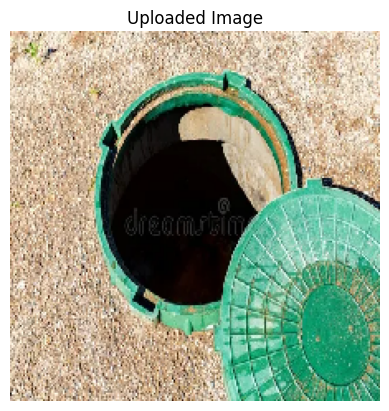

In [22]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Define the class labels (alphabetical if using flow_from_directory)
class_labels = ['Garbage', 'manhole', 'pothole']  # Adjust order if needed

# Load and preprocess image
img_path = list(uploaded.keys())[0]  # Get the uploaded file name
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

# Show image
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()


In [23]:
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
predicted_class = class_labels[predicted_index]

print(f"🧠 Predicted class: {predicted_class}")
print(f"🔢 Confidence: {pred[0][predicted_index]:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
🧠 Predicted class: manhole
🔢 Confidence: 99.96%
